In [95]:
#Importing laibraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [96]:
#Loading data from movie.csv
movies = pd.read_csv('DATA/movies.csv')
movies.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"Action,Crime,Drama",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"Adventure,Drama,Romance",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"Adventure,Comedy,Drama",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"Action,Crime,Drama",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"Action,Adventure,Sci-Fi",124.0,7.0,539338,Uni.,652300000.0,1019.4


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

sg = (
    movies.assign(genres=movies['genres'].str.split(','))
          .explode('genres')
          .assign(genres=lambda df: df['genres'].str.strip())
)
sg


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,Action,103.0,7.1,15378,Relbig.,1100000.0,0.0
0,Wazir,2016,Crime,103.0,7.1,15378,Relbig.,1100000.0,0.0
0,Wazir,2016,Drama,103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0
...,...,...,...,...,...,...,...,...,...
3052,Neighbors,2018,Drama,90.0,7.6,18,Uni.,150200000.0,120500000.0
3053,The Gambler,2019,Action,121.0,6.1,10,Par.,33700000.0,5600000.0
3053,The Gambler,2019,Sci-Fi,121.0,6.1,10,Par.,33700000.0,5600000.0
3053,The Gambler,2019,Thriller,121.0,6.1,10,Par.,33700000.0,5600000.0


## how is the competition and what niches can we exploit for a start (studio)

### studio vs genres

In [98]:

#Filter to top 8 studios & genres
top_studios = sg['studio'].value_counts().nlargest(8).index
top_genres = sg['genres'].value_counts().nlargest(8).index
studio_genre_df = sg[sg['studio'].isin(top_studios) & 
                       sg['genres'].isin(top_genres)]
studio_genre_df #top studios, top genres


,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
1,On the Road,2012,Adventure,124.0,6.1,37886,IFC,744000.0,8000000.0
1,On the Road,2012,Drama,124.0,6.1,37886,IFC,744000.0,8000000.0
1,On the Road,2012,Romance,124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,Adventure,114.0,7.3,275300,Fox,58200000.0,129900000.0
2,The Secret Life of Walter Mitty,2013,Comedy,114.0,7.3,275300,Fox,58200000.0,129900000.0
...,...,...,...,...,...,...,...,...,...
3045,Joy,2018,Drama,99.0,6.5,430,Fox,56500000.0,44700000.0
3051,Unstoppable,2018,Action,116.0,6.5,576,Fox,81600000.0,86200000.0
3051,Unstoppable,2018,Crime,116.0,6.5,576,Fox,81600000.0,86200000.0
3052,Neighbors,2018,Comedy,90.0,7.6,18,Uni.,150200000.0,120500000.0


##### Chi-square test to conclude whether or not there is a relationship between Studios and Genres


 - Create contingency table
 - Conduct **chi-square test of independence** to assess relationship between studios and genres by comparing observed counts to counts expected, initially assuming they were **independent**
 

In [104]:


cross_tabulation = pd.crosstab(studio_genre_df['studio'], studio_genre_df['genres'])
chi_square, p_value, _, expected = stats.chi2_contingency(cross_tabulation)
print(f'chi-square = {chi_square:.2f}\np-value = {p_value:.10f}')
cross_tabulation

chi-square = 426.88
p-value = 0.0000000000


genres,Action,Adventure,Biography,Comedy,Crime,Drama,Romance,Thriller
studio,,,,,,,,
BV,30,58,9,38,3,24,5,3
Fox,47,53,8,56,16,50,10,15
IFC,5,5,11,38,22,114,32,20
Magn.,26,9,11,26,14,72,13,26
SPC,2,2,26,29,6,87,35,14
Sony,38,30,7,48,17,31,10,20
Uni.,53,33,12,63,18,56,25,35
WB,52,39,10,42,23,62,10,15


**Observations**
 - **H0 (*Null Hypothesis*)**: Studios and genres are independent. (No association)
 - The **p-value** is **0.0000**: Staggeringly low p-value. Strongly indicating extreme evidence against the null hypothesis of independence.

**Decision**
 - Assuming an alpha level of 0.05, we **reject the null hypothesis**.
 - In turn concluding that there _is_ a statistically significant association between studios and genres.
 

**Visualization** 
 - Visualizing the existing relationship between studios and genres using a stacked bar chart showing proportionally which genres are favoured by the top 8 studios.

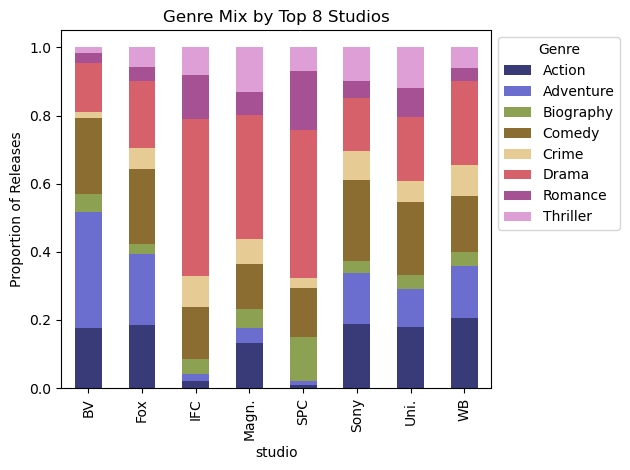

In [105]:
genre_studio_mix = cross_tabulation.div(cross_tabulation.sum(axis=1), axis=0)
genre_studio_mix.plot(kind='bar', stacked=True,  cmap='tab20b')
plt.legend(title='Genre', bbox_to_anchor=(1,1))
plt.title('Genre Mix by Top 8 Studios')
plt.ylabel('Proportion of Releases')
plt.tight_layout()
plt.show()

##### Calculating Standardized Residuals to determine how strongly the two variables are related

 - Calculate **std_residuals** by dividing the difference between observed and expected counts by the square root of the expected counts.
 - Visualize std_residuals (a dataframe) by plotting a heatmap that shows the strength of the relationship between each studios and genres.

In [106]:
std_residuals = (cross_tabulation - expected) / np.sqrt(expected)
std_residuals

genres,Action,Adventure,Biography,Comedy,Crime,Drama,Romance,Thriller
studio,,,,,,,,
BV,1.306943,7.911030,0.072522,1.104188,-2.435311,-3.283435,-2.234911,-2.912465
Fox,1.936499,3.688218,-1.426292,1.207502,-0.167037,-2.342437,-2.172880,-1.261847
IFC,-5.008223,-4.679704,-0.493788,-1.202143,1.453084,5.684165,2.979189,-0.021583
Magn.,-0.267497,-3.172852,0.256900,-1.783481,0.309794,2.494478,-0.555278,2.490629
SPC,-4.909139,-4.632779,4.844400,-1.398184,-1.971617,4.348341,4.965417,-0.582105
Sony,1.899504,0.933419,-1.050928,1.701607,1.061838,-3.215903,-1.390736,0.901570
Uni.,1.868576,-0.679101,-0.831013,1.058469,-0.295708,-2.724973,0.481687,2.244814
WB,2.833912,1.266726,-0.850211,-0.769218,1.585068,-0.841256,-2.146568,-1.230959


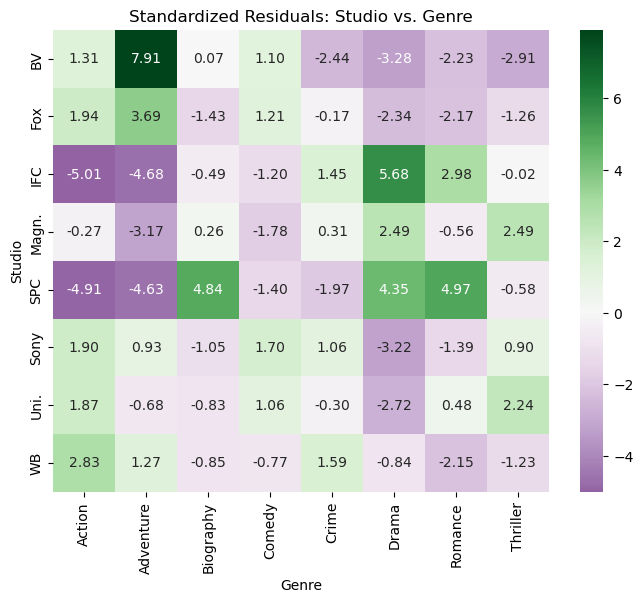

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(std_residuals, annot=True, center=0, fmt=".2f", cmap="PRGn")
plt.title('Standardized Residuals: Studio vs. Genre')
plt.xlabel('Genre')
plt.ylabel('Studio')
plt.show()

In [103]:
underserved = std_residuals.stack().loc[lambda x: x <= -2]
print("\nUnder-represented genre–studio combos (std_resid ≤ -2):")
print(underserved)



Under-represented genre–studio combos (std_resid ≤ -2):
studio  genres   
BV      Crime       -2.435311
        Drama       -3.283435
        Romance     -2.234911
        Thriller    -2.912465
Fox     Drama       -2.342437
        Romance     -2.172880
IFC     Action      -5.008223
        Adventure   -4.679704
Magn.   Adventure   -3.172852
SPC     Action      -4.909139
        Adventure   -4.632779
Sony    Drama       -3.215903
Uni.    Drama       -2.724973
WB      Romance     -2.146568
dtype: float64


 - Big Studios neglect Drama/Romance - a new studio can build an audience with emotionally driven, mid-budget Drama/Romance films. 

 - Independent studios neglect Action and Adventure genres and can be promising avenue 